# 프로젝트 2: 품질관리 - 불량 원인 & SPC 분석

## 프로젝트 배경

당신은 **한국정밀산업(주)** 품질관리팀의 데이터 분석가입니다.  
최근 주요 고객사로부터 다음과 같은 클레임이 접수되었습니다:

> *"납품받은 샤프트-A(PRD-003) 제품의 직경 치수가 규격을 벗어나는 건이 빈번합니다.  
> 또한 5월 이후 기어박스커버(PRD-005)의 두께가 점점 커지고 있는 것 같습니다.  
> 공정능력(Cpk) 분석 자료와 개선 대책을 제출해 주세요."*

품질팀장은 당신에게 다음 분석을 요청했습니다:

### 분석 목표
1. **불량 현황 파악** - 어떤 유형의 불량이 가장 많고, 어디서 발생하는가?
2. **파레토 분석** - 80/20 법칙으로 핵심 불량 원인 도출
3. **SPC 관리도** - 공정이 관리 상태인지, 특수원인은 없는지 확인
4. **공정능력 분석** - Cp/Cpk로 공정이 규격을 충족하는지 정량 평가
5. **공정 파라미터 영향 분석** - 온도·진동 등이 품질에 미치는 영향 분석

### 데이터 설명

| 파일 | 설명 | 주요 컬럼 |
|------|------|----------|
| `p2_product_spec.csv` | 제품별 측정항목 규격 (24건) | product_code, spec_name, target_value, lsl, usl |
| `p2_inspection_log.csv` | 품질 측정 기록 (~42,000건) | lot_no, measurement, result, inspector_id |
| `p2_defect_log.csv` | 불량 상세 기록 (~770건) | defect_type, cause, severity, defect_qty |
| `p2_process_params.csv` | 공정 파라미터 (~1,700건) | temperature_c, vibration_mms, has_defect |

### SPC 핵심 개념

```
공정능력지수 (Cp)  = (USL - LSL) / (6σ)        → 산포 대비 공차 여유
치우침 공정능력 (Cpk) = min(CPU, CPL)            → 편향까지 고려
  CPU = (USL - X̄) / (3σ)
  CPL = (X̄ - LSL) / (3σ)

판정 기준:
  Cpk ≥ 1.33 : 공정능력 충분
  1.0 ≤ Cpk < 1.33 : 관리 필요
  Cpk < 1.0 : 공정능력 부족 → 개선 필수
```

---

## Part 0: 환경 설정 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

# 데이터 로드
spec = pd.read_csv('../data/project2/p2_product_spec.csv', encoding='utf-8-sig')
insp = pd.read_csv('../data/project2/p2_inspection_log.csv', encoding='utf-8-sig')
defect = pd.read_csv('../data/project2/p2_defect_log.csv', encoding='utf-8-sig')
params = pd.read_csv('../data/project2/p2_process_params.csv', encoding='utf-8-sig')

# 날짜 변환
insp['inspection_date'] = pd.to_datetime(insp['inspection_date'])
defect['defect_date'] = pd.to_datetime(defect['defect_date'])
params['record_date'] = pd.to_datetime(params['record_date'])

print('데이터 로드 완료!')
print(f'규격: {len(spec)}건 | 측정: {len(insp):,}건 | 불량: {len(defect)}건 | 공정파라미터: {len(params):,}건')

데이터 로드 완료!
규격: 24건 | 측정: 42,560건 | 불량: 767건 | 공정파라미터: 1,716건


---
## Part 1: 데이터 탐색 및 전처리 (15점)

품질 데이터는 여러 소스에서 수집됩니다.  
검사 장비 오류, 미기록, 검사원 실수 등으로 결측치가 존재합니다.

### 문제 1-1: 데이터 탐색 (5점)

1. 4개 데이터프레임의 shape, 컬럼, 처음 5행을 확인하세요
2. `spec` 테이블에서 제품별 측정항목 수를 확인하세요
3. `insp` 테이블의 결측치 현황을 파악하세요
4. `defect` 테이블의 결측치 현황을 파악하세요
5. `insp`의 `result` 컬럼에서 PASS/FAIL 비율을 확인하세요

In [2]:
# 여기에 코드 작성
spec

,product_code,product_name,spec_name,unit,target_value,lsl,usl,tolerance
0,PRD-001,베어링하우징-S,외경,mm,50.0,49.95,50.050,0.100
1,PRD-001,베어링하우징-S,내경,mm,30.0,29.96,30.040,0.080
2,PRD-001,베어링하우징-S,높이,mm,25.0,24.95,25.050,0.100
3,PRD-001,베어링하우징-S,표면조도,Ra,1.6,0.00,3.200,3.200
4,PRD-002,베어링하우징-M,외경,mm,80.0,79.94,80.060,0.120
5,PRD-002,베어링하우징-M,내경,mm,50.0,49.95,50.050,0.100
6,PRD-002,베어링하우징-M,높이,mm,40.0,39.94,40.060,0.120
7,PRD-002,베어링하우징-M,표면조도,Ra,1.6,0.00,3.200,3.200
8,PRD-003,샤프트-A,직경,mm,20.0,19.98,20.020,0.040
9,PRD-003,샤프트-A,길이,mm,150.0,149.90,150.100,0.200


In [3]:
spec.groupby('product_code')['spec_name'].count() #제품별로 4개씩 확인

product_code
PRD-001    4
PRD-002    4
PRD-003    4
PRD-004    4
PRD-005    4
PRD-006    4
Name: spec_name, dtype: int64

In [4]:
insp.head(2)

,inspection_id,lot_id,lot_no,inspection_date,shift,line,product_code,spec_name,unit,target_value,lsl,usl,measurement,result,sample_no,inspector_id
0,QC-000001,L00001,LOT-240101-A주-001,2024-01-01,주간,A라인,PRD-001,외경,mm,50.0,49.95,50.05,50.0285,PASS,1,INS-07
1,QC-000002,L00001,LOT-240101-A주-001,2024-01-01,주간,A라인,PRD-001,내경,mm,30.0,29.96,30.04,30.0110,PASS,1,INS-07


In [5]:
defect.head(2)

,defect_id,defect_date,line,shift,product_code,defect_type,cause,severity,defect_qty,action,inspector_id
0,DEF-00001,2024-01-01,A라인,야간,PRD-004,외관불량,스크래치,보통,11,재작업,INS-05
1,DEF-00002,2024-01-01,A라인,주간,PRD-001,표면조도불량,소재불량,보통,1,특채(조건부합격),INS-05


In [6]:
params.head(2)

,param_id,record_date,shift,line,product_code,temperature_c,pressure_bar,spindle_speed_rpm,feed_rate_mmmin,coolant_flow_lmin,vibration_mms,has_defect
0,PP-00001,2024-01-01,주간,A라인,PRD-004,42.8,3.75,3343.0,217.5,14.8,0.526,0
1,PP-00002,2024-01-01,주간,A라인,PRD-001,40.0,5.23,2751.0,207.9,16.2,0.323,0


In [7]:
spec.nunique()

product_code     6
product_name     6
spec_name       11
unit             2
target_value    18
lsl             15
usl             20
tolerance       15
dtype: int64

In [8]:
insp.isna().sum()

inspection_id         0
lot_id                0
lot_no                0
inspection_date       0
shift                 0
line                  0
product_code          0
spec_name             0
unit                  0
target_value          0
lsl                   0
usl                   0
measurement        1258
result             1258
sample_no             0
inspector_id          0
dtype: int64

In [9]:
defect.isna().sum()

defect_id        0
defect_date      0
line             0
shift            0
product_code     0
defect_type      0
cause           32
severity         0
defect_qty       0
action           6
inspector_id     0
dtype: int64

In [10]:
insp.head(2)

,inspection_id,lot_id,lot_no,inspection_date,shift,line,product_code,spec_name,unit,target_value,lsl,usl,measurement,result,sample_no,inspector_id
0,QC-000001,L00001,LOT-240101-A주-001,2024-01-01,주간,A라인,PRD-001,외경,mm,50.0,49.95,50.05,50.0285,PASS,1,INS-07
1,QC-000002,L00001,LOT-240101-A주-001,2024-01-01,주간,A라인,PRD-001,내경,mm,30.0,29.96,30.04,30.0110,PASS,1,INS-07


In [11]:
insp['inspection_id'].count()

np.int64(42560)

In [12]:
insp[insp['result']=='PASS']['result'].count()

np.int64(40909)

In [13]:
insp[insp['result']=='FAIL']['result'].count()

np.int64(393)

In [14]:
insp[insp['result']=='PASS']['result'].count()/insp['inspection_id'].count()*100 # PASS 비율

np.float64(96.12077067669172)

In [15]:
insp[insp['result']=='FAIL']['result'].count()/insp['inspection_id'].count()*100 #FAIL 비욜

np.float64(0.9234022556390978)

### 문제 1-2: 결측치 처리 (5점)

1. `insp`에서 `measurement`가 NaN인 행은 **측정 장비 오류**입니다 → 해당 행 삭제
2. `defect`에서 `cause`가 NaN인 건은 → `'원인미상'`으로 대체
3. `defect`에서 `action`이 NaN인 건은 → `'미처리'`로 대체
4. `params`에서 수치형 컬럼의 NaN은 → 해당 라인의 평균값으로 대체
5. 처리 후 모든 테이블의 결측치가 0인지 확인

In [16]:
insp.dropna(subset=['measurement'], inplace=True)

In [17]:
insp.isna().sum()

inspection_id      0
lot_id             0
lot_no             0
inspection_date    0
shift              0
line               0
product_code       0
spec_name          0
unit               0
target_value       0
lsl                0
usl                0
measurement        0
result             0
sample_no          0
inspector_id       0
dtype: int64

In [31]:
defect['cause'].fillna('원인미상', inplace=True)

In [32]:
defect['action'].fillna('미처리', inplace=True)

In [33]:
defect.isna().sum()

defect_id       0
defect_date     0
line            0
shift           0
product_code    0
defect_type     0
cause           0
severity        0
defect_qty      0
action          0
inspector_id    0
dtype: int64

In [35]:
params.isna().sum()

param_id              0
record_date           0
shift                 0
line                  0
product_code          0
temperature_c        36
pressure_bar          0
spindle_speed_rpm     0
feed_rate_mmmin       0
coolant_flow_lmin    42
vibration_mms        57
has_defect            0
dtype: int64

In [36]:
params.head(2)

,param_id,record_date,shift,line,product_code,temperature_c,pressure_bar,spindle_speed_rpm,feed_rate_mmmin,coolant_flow_lmin,vibration_mms,has_defect
0,PP-00001,2024-01-01,주간,A라인,PRD-004,42.8,3.75,3343.0,217.5,14.8,0.526,0
1,PP-00002,2024-01-01,주간,A라인,PRD-001,40.0,5.23,2751.0,207.9,16.2,0.323,0


In [38]:
params['temperature_c'].fillna(params.groupby('line')['temperature_c'].transform('mean'),inplace=True)

In [39]:
params['coolant_flow_lmin'].fillna(params.groupby('line')['coolant_flow_lmin'].transform('mean'),inplace=True)

In [40]:
params['vibration_mms'].fillna(params.groupby('line')['vibration_mms'].transform('mean'),inplace=True)

In [41]:
params.isna().sum()

param_id             0
record_date          0
shift                0
line                 0
product_code         0
temperature_c        0
pressure_bar         0
spindle_speed_rpm    0
feed_rate_mmmin      0
coolant_flow_lmin    0
vibration_mms        0
has_defect           0
dtype: int64

### 문제 1-3: 파생 컬럼 생성 (5점)

`insp` 테이블에 분석용 파생 컬럼을 추가하세요:

1. `month` - 검사월
2. `deviation` - 편차 = measurement - target_value (목표값 대비 얼마나 벗어났는가)
3. `is_fail` - FAIL 여부 (0 또는 1)
4. `within_spec` - 규격 이내 여부 (True/False, lsl ≤ measurement ≤ usl)

`defect` 테이블에도 추가:
5. `month` - 불량 발생월

In [42]:
# 여기에 코드 작성
insp.head(2)


,inspection_id,lot_id,lot_no,inspection_date,shift,line,product_code,spec_name,unit,target_value,lsl,usl,measurement,result,sample_no,inspector_id
0,QC-000001,L00001,LOT-240101-A주-001,2024-01-01,주간,A라인,PRD-001,외경,mm,50.0,49.95,50.05,50.0285,PASS,1,INS-07
1,QC-000002,L00001,LOT-240101-A주-001,2024-01-01,주간,A라인,PRD-001,내경,mm,30.0,29.96,30.04,30.0110,PASS,1,INS-07


In [45]:
insp['month']=insp['inspection_date'].dt.month

In [47]:
insp['deviation']=insp['measurement']-insp['target_value']

In [49]:
insp['is_fail']=np.where(insp['result']=='FAIL',1,0)

In [55]:
insp['within_spec']=np.where((insp['lsl']<=insp['measurement'])&(insp['measurement']<=insp['usl']),'True','False')

In [57]:
defect['month']=defect['defect_date'].dt.month

---
## Part 2: 불량 분석 (25점)

품질관리의 첫 단계는 **현황 파악**입니다.  
어떤 불량이 가장 많이 발생하고, 어디서, 왜 발생하는지 데이터로 확인합니다.

> **현업 포인트**: 파레토 법칙(80/20 법칙) - 상위 20%의 원인이 전체 불량의 80%를 차지합니다.  
> 모든 문제를 동시에 해결하려 하지 말고, 핵심 소수에 집중하세요.

### 문제 2-1: 불량 유형별 파레토 분석 (10점)

1. 불량 유형별 **불량 수량(defect_qty) 합계**를 집계하세요 (건수가 아니라 수량!)
2. 내림차순 정렬 후 **누적 비율(%)**을 계산하세요
3. **파레토 차트**를 그리세요:
   - 막대: 불량 유형별 수량 합계
   - 선: 누적 비율 (%)
   - 80% 기준선 표시
   - Figure 크기: (12, 6)
4. 상위 2~3개 유형으로 전체 불량의 80% 이상을 설명할 수 있는지 확인

In [63]:
# 여기에 코드 작성
defect_type=defect.groupby('defect_type').agg({'defect_qty':'sum'})

In [ ]:
defect_type.sort_values('defect_qty',ascending=False, inplace=True)

In [68]:
defect_type

,defect_qty
defect_type,
외관불량,2320
치수불량,1824
표면조도불량,879
형상불량,852
크랙,507
기타,437


In [77]:
defect_type_ratio=defect_type.cumsum()/defect_type.sum()*100

In [80]:
from koreanize_matplotlib import koreanize
koreanize()

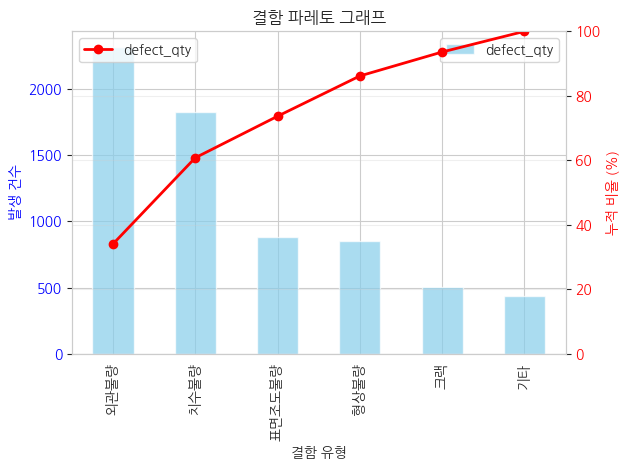

In [88]:
fig, ax1 = plt.subplots()
defect_type.plot(kind='bar', ax=ax1, color='skyblue', alpha=0.7)
ax1.set_xlabel('결함 유형')
ax1.set_ylabel('발생 건수', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
defect_type_ratio.plot(kind='line', ax=ax2, color='red', marker='o', linewidth=2)
ax2.set_ylabel('누적 비율 (%)', color='red')
ax2.set_ylim(0, 100)
ax2.tick_params(axis='y', labelcolor='red')
ax2.grid(True, alpha=0.3)

plt.title('결함 파레토 그래프')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 문제 2-2: 라인별·제품별 불량 분석 (5점)

1. 라인별 불량 수량 합계와 불량 건수를 비교하세요
2. `line`(행) × `defect_type`(열)의 불량 수량 피벗 테이블 → **히트맵**
3. 제품별 불량 수량 Top 5를 구하고, 어떤 불량 유형이 주로 발생하는지 확인

In [89]:
# 여기에 코드 작성
defect.head(2)

,defect_id,defect_date,line,shift,product_code,defect_type,cause,severity,defect_qty,action,inspector_id,month
0,DEF-00001,2024-01-01,A라인,야간,PRD-004,외관불량,스크래치,보통,11,재작업,INS-05,1
1,DEF-00002,2024-01-01,A라인,주간,PRD-001,표면조도불량,소재불량,보통,1,특채(조건부합격),INS-05,1


In [91]:
defect.groupby('line').agg(
    불량건수_개수=('defect_id', 'count'),
    불량수량_합계=('defect_qty', 'sum')
)

,불량건수_개수,불량수량_합계
line,,
A라인,321,2986
B라인,204,1796
C라인,242,2037


In [93]:
pivot_line_type=pd.pivot_table(defect,index='line',columns='defect_type',values='defect_qty',aggfunc='sum')

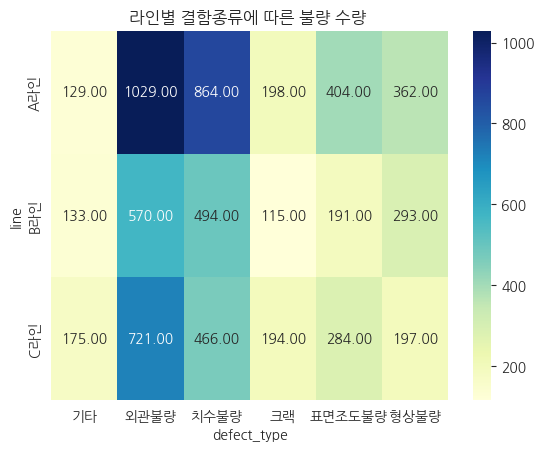

In [106]:
sns.heatmap(data=pivot_line_type,cmap='YlGnBu' ,annot=True, fmt='.2f')
plt.title('라인별 결함종류에 따른 불량 수량 ')
plt.show()

In [111]:
group_bar=defect.groupby(['product_code','defect_type']).agg(
    불량수량_합계=('defect_qty', 'sum')
).unstack()

<Axes: xlabel='product_code'>

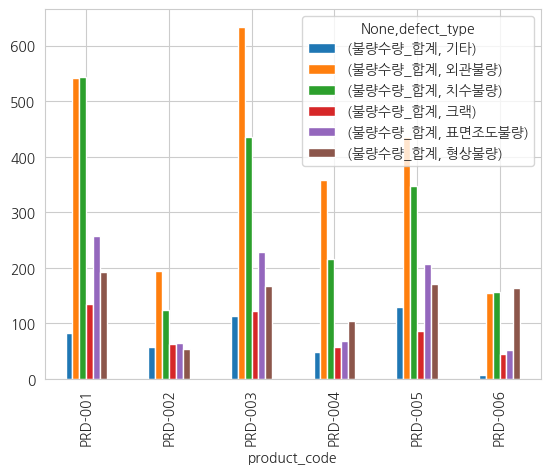

In [112]:
group_bar.plot(kind='bar')

### 문제 2-3: 월별 불량 추이 분석 (5점)

1. 월별 총 불량 수량 추이를 **라인별 라인 차트**로 시각화
2. 5월 이후 B라인 불량이 증가했는지 확인
3. 심각도(severity)별 월별 추이도 확인하세요

> B라인에서 5월 이후 이상 징후가 보이면 Part 3에서 SPC로 원인을 추적합니다.

In [21]:
# 여기에 코드 작성


### 문제 2-4: 불량 원인 심층 분석 (5점)

외관불량이 가장 많다면, 그 세부 원인은 무엇인가?

1. 불량 유형별 **세부 원인(cause)** 건수를 집계하세요
2. 상위 3개 불량 유형 각각의 원인 분포를 **서브플롯(1×3)**으로 시각화
   - 각 서브플롯은 수평 막대 차트
3. 불량 처리 방법(action)별 비율도 확인 (재작업 vs 폐기 vs 특채)

In [22]:
# 여기에 코드 작성


---
## Part 3: SPC 관리도 & 공정능력 분석 (30점)

**SPC(Statistical Process Control, 통계적 공정 관리)**는  
공정의 변동을 **우연원인**(자연스러운 산포)과 **특수원인**(이상 변동)으로 구분합니다.

### 관리도의 핵심 개념

```
중심선 (CL) = 전체 평균 (X̄)
관리 상한 (UCL) = X̄ + 3σ
관리 하한 (LCL) = X̄ - 3σ

관리 이탈 판정 규칙 (Nelson Rules 중 기본):
  Rule 1: 점이 UCL/LCL 밖에 위치
  Rule 2: 연속 7개 점이 중심선 같은 쪽
```

> **현업 포인트**: 관리도에서 '이탈'이 발견되면 즉시 현장에 알리고 원인을 조사합니다.  
> 관리도는 '판정 도구'가 아니라 '신호 탐지 도구'입니다.

### 문제 3-1: PRD-003(샤프트-A) 직경 관리도 (10점)

고객이 클레임한 PRD-003 직경을 SPC로 분석합니다.

1. `insp`에서 PRD-003 + 직경 데이터만 필터링
2. 로트별(lot_id) 평균값(X̄)과 범위(R)를 계산하세요
3. **X̄-R 관리도**를 그리세요 (2행 1열 서브플롯):
   - 상단: X̄ 관리도 (CL, UCL, LCL, 규격선 USL/LSL 포함)
   - 하단: R 관리도 (CL, UCL)
   - 관리 이탈점은 빨간색으로 표시
   - Figure 크기: (16, 10)

**X̄ 관리도 계수 (n=5일 때):**
```
A2 = 0.577
D3 = 0
D4 = 2.114

X̄ 관리도:
  CL = X̿ (X̄들의 전체 평균)
  UCL = X̿ + A2 × R̄
  LCL = X̿ - A2 × R̄

R 관리도:
  CL = R̄ (R들의 평균)
  UCL = D4 × R̄
  LCL = D3 × R̄
```

In [23]:
# 여기에 코드 작성


### 문제 3-2: PRD-003 직경 공정능력 분석 (10점)

관리도로 공정 상태를 확인했으면, 이제 **공정이 규격을 만족하는지** 정량 평가합니다.

1. PRD-003 직경의 **전체** Cp, Cpk를 계산하세요
2. **라인별** Cp, Cpk를 계산하세요 (A라인 vs C라인)
3. Cpk 판정 결과를 해석하세요:
   - Cpk ≥ 1.33: 충분 / 1.0 ≤ Cpk < 1.33: 관리필요 / Cpk < 1.0: 부족
4. **히스토그램 + 규격선** 차트를 그리세요:
   - 라인별 (1×2 서브플롯)
   - 히스토그램 위에 정규분포 커브 오버레이
   - USL, LSL, Target 세로선 표시
   - Cp, Cpk 값을 차트 안에 텍스트로 표시
   - Figure 크기: (14, 5)

In [24]:
# 여기에 코드 작성


### 문제 3-3: PRD-005(기어박스커버) 두께 이상 탐지 (10점)

고객이 "5월 이후 두께가 커지고 있다"고 했습니다.  
SPC 관리도로 **특수원인 변동**을 탐지하세요.

1. PRD-005 + 두께 데이터를 필터링
2. **월별 평균**을 계산하여 추이를 확인
3. **1~4월 데이터만**으로 관리한계(CL, UCL, LCL)를 설정하세요  
   (정상 기간 기준으로 관리한계를 설정해야 5월 이후 이상을 탐지할 수 있음)
4. **개별값 관리도(I-MR chart)**를 그리세요:
   - 로트별 평균을 시계열로 표시
   - 1~4월 기준 관리한계선
   - 5월 이후 이탈점 빨간색 표시
   - Figure 크기: (16, 6)
5. Nelson Rule 2 (연속 7점 같은 쪽) 위반 여부도 확인

In [25]:
# 여기에 코드 작성


---
## Part 4: 공정 파라미터 영향 분석 (15점)

불량의 원인을 찾으려면 **공정 조건(파라미터)**과 **품질 결과**의 관계를 분석해야 합니다.  
온도가 높으면 열변형이 발생하고, 진동이 크면 표면 품질이 나빠질 수 있습니다.

> **현업 포인트**: 상관관계 ≠ 인과관계이지만, 상관이 있는 파라미터는 관리 우선순위가 높습니다.

### 문제 4-1: 공정 파라미터 상관관계 분석 (5점)

1. `params`의 수치형 컬럼 간 **상관관계 히트맵**을 그리세요
   - `annot=True, fmt='.2f', cmap='coolwarm', center=0`
2. `has_defect`(불량 발생 여부)와 가장 상관이 높은 파라미터는?
3. 라인별로 상관관계가 다른지 비교하세요 (라인별 3개 히트맵)

In [26]:
# 여기에 코드 작성


### 문제 4-2: 불량 발생 조건 분석 (5점)

1. `has_defect == 1`(불량 발생)과 `has_defect == 0`(정상) 그룹의  
   주요 파라미터 평균을 비교하는 표를 만드세요
2. **온도(temperature_c) 구간별 불량률**을 계산하세요:
   - 구간: ~35, 35~40, 40~45, 45~50, 50~ (pd.cut 사용)
   - 구간별 불량률 = has_defect 합계 / 건수 × 100
   - **막대 차트**로 시각화
3. 불량 발생 임계 온도가 있는지 확인

In [27]:
# 여기에 코드 작성


### 문제 4-3: 검사원별 측정 편차 분석 (5점)

측정 시스템 신뢰성도 중요합니다.  
같은 제품을 다른 검사원이 측정했을 때 결과가 달라지면 문제입니다.

1. PRD-001 외경에 대해 **검사원별 평균 측정값**을 비교하세요
2. **박스플롯**으로 검사원별 측정값 분포를 비교 (x=inspector_id, y=measurement)
3. 특정 검사원(INS-07, INS-08)의 측정값이 다른 검사원보다 체계적으로 높은지 확인
4. 검사원 간 차이가 유의한지 **ANOVA (일원분산분석)** 수행
   - `stats.f_oneway(group1, group2, ...)` 사용

In [28]:
# 여기에 코드 작성


---
## Part 5: 품질 종합 보고서 대시보드 (15점)

분석 결과를 **품질 관리 보고서 형태의 대시보드**로 정리합니다.

### 문제 5-1: 품질 종합 대시보드 (15점)

`plt.subplot()` 또는 `GridSpec`으로 **2행 3열 (6패널)** 대시보드를 만드세요.  
Figure 크기: (20, 12)

| 위치 | 차트 | 내용 |
|------|------|------|
| (1,1) | 파레토 차트 | 불량 유형별 수량 + 누적비율 |
| (1,2) | 히트맵 | 라인 × 불량유형 불량수량 |
| (1,3) | 라인 차트 | 월별 불량 수량 추이 (라인별) |
| (2,1) | 히스토그램 | PRD-003 직경 분포 + 규격선 |
| (2,2) | 관리도 | PRD-005 두께 시계열 (관리한계 포함) |
| (2,3) | 막대 차트 | 온도 구간별 불량률 |

**스타일:**
- 전체 제목: '한국정밀산업(주) 품질관리 보고서 (2024년 상반기)'
- 각 패널에 소제목
- `plt.tight_layout()` 적용

In [29]:
# 여기에 코드 작성


---
## 분석 결론 작성

고객 클레임에 대응하기 위한 분석 보고서를 작성하세요:

1. **불량 현황 요약**: 주요 불량 유형과 발생 패턴
2. **PRD-003 샤프트-A 직경 문제**: Cpk 수치, 문제의 심각성, 라인별 차이
3. **PRD-005 기어박스커버 두께 이상**: 5월 이후 평균 이동 원인 추정
4. **공정 파라미터 영향**: 온도·진동과 품질의 관계
5. **검사 시스템 문제**: 검사원 간 편차 여부
6. **개선 제안**: 구체적인 3가지 이상의 조치 방안

### 분석 결론 (여기에 작성)

1. **불량 현황 요약**: 

2. **PRD-003 직경 문제**: 

3. **PRD-005 두께 이상**: 

4. **공정 파라미터 영향**: 

5. **검사 시스템 문제**: 

6. **개선 제안**: 


---
## 수고하셨습니다!

### 학습 체크리스트
- [ ] 파레토 분석으로 핵심 불량 원인 도출
- [ ] 라인별·제품별·월별 불량 추이 분석
- [ ] X̄-R 관리도 작성 및 관리 이탈점 식별
- [ ] 공정능력지수 Cp/Cpk 계산 및 해석
- [ ] 히스토그램 + 규격선으로 공정능력 시각화
- [ ] 특수원인 변동 탐지 (평균 이동)
- [ ] 공정 파라미터와 품질의 상관관계 분석
- [ ] 검사원 간 측정 편차 분석 (ANOVA)
- [ ] 종합 품질 대시보드 구성